# Compare duplicate values of morphology

The goals of this notebook are to:
- compare the morphology metrics in the R and Halpha images
- quantify the uncertainty in each metric to use with downstream analysis

In [57]:
import numpy as np
from matplotlib import pyplot as plt
import os

In [60]:
os.chdir('/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260319')
os.chdir('/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260407')

In [61]:
%run ~/github/havirgo/python/hapy_duplicates.py 

number of duplicate observations = 184


Text(0, 0.5, 'data 2')

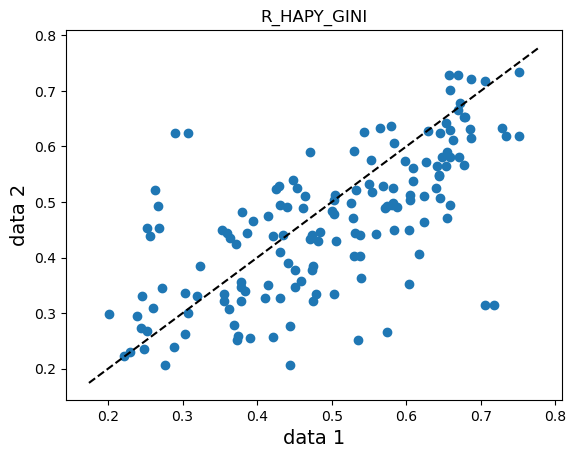

In [64]:
plt.figure()
colname = 'R_HAPY_GINI'
var = d.htab[colname]
plt.scatter(var[d.dupindex1],var[d.dupindex2])
x1,x2 = plt.xlim()
xline = np.linspace(x1,x2,100)
plt.plot(xline,xline,'k--')

plt.title(colname)
plt.xlabel("data 1",fontsize=14)
plt.ylabel("data 2",fontsize=14)

In [17]:
morphs=['GINI','M20','ASY']
for m in morphs:
    for c in d.htab.colnames:
        #if 'GINI' in c:
        if m in c:
            print(c)
    print()

R_ELLIP_GINI
H_ELLIP_GINI
H_GINI_THRESHOLD
R_HAPY_GINI
H_HAPY_GINI
R_SM_GINI
H_SM_GINI

R_M20
H_M20
R_HAPY_M20
H_HAPY_M20
R_SM_M20
H_SM_M20

R_ASYM
R_ASYM_ERR
H_ASYM
H_ASYM_ERR



In [35]:
morphs = ['_ELLIP_GINI','_HAPY_GINI','_SM_GINI',\
            '_M20','_HAPY_M20','_SM_M20',\
             "_SM_C", "_SM_A","_SM_S",
             "_ASYM", "_C30"
            ]
rmorph_cols=['R'+m for m in morphs]
hmorph_cols=['H'+m for m in morphs]
hmorph_cols.remove("H_C30")

In [65]:
%run ~/github/havirgo/python/hapy_duplicates.py 
d.get_augmented_table()

tier = np.zeros(len(d.htab))

for i in range(len(d.htab)):
    for j,l in enumerate(['A','B','C','D','E','F']):
        if d.htab['QC_TIER'][i] == l:
            tier[i] = j
d.htab.add_column(np.array(tier,'d'),name="N_TIER")

number of duplicate observations = 184
REVIEW_PRIORITY SUMMARY
{'high': 118, 'low': 302, 'medium': 403}
ELL_MISMATCH 290
FILTER_WARNING 79
WARN_MASK 28
BRIGHT_STAR_FLAG 7
WARN_WEAK_HA 224


/Users/rfinn/anaconda3/envs/virgo/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan


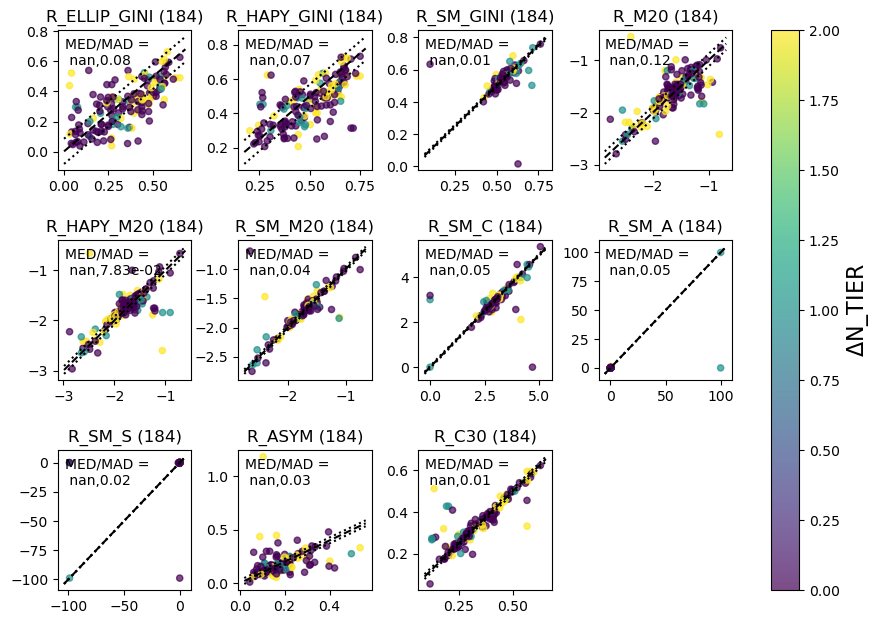

In [66]:
#%run ~/github/havirgo/python/hapy_duplicates.py 
pairplot_linear(d.htab,rmorph_cols,d.dupindex1,d.dupindex2,colorcolumn="N_TIER",v1=0.,v2=2)

med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan
med =  nan


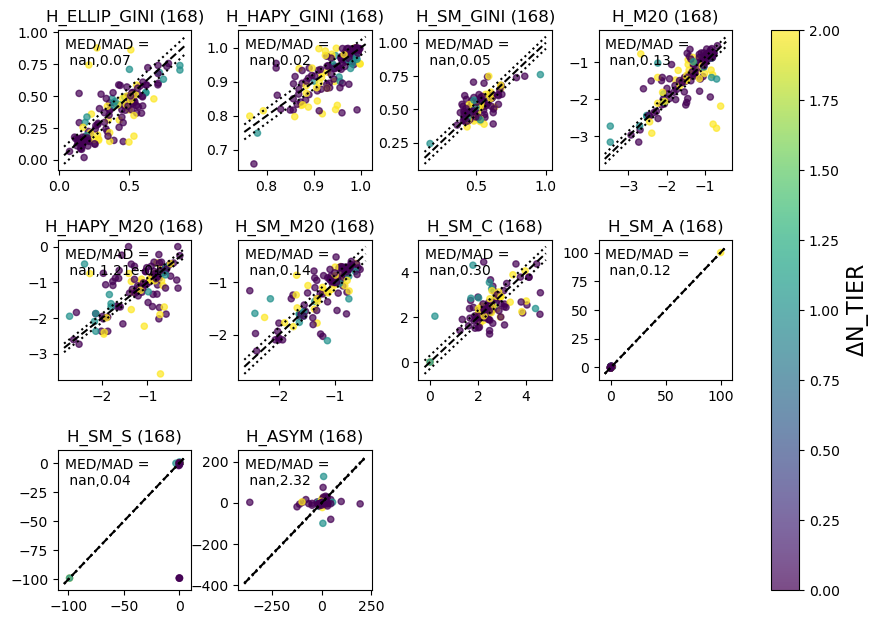

In [56]:
#%run ~/github/havirgo/python/hapy_duplicates.py 
pairplot_linear(d.htab,hmorph_cols,d.dupindex1,d.dupindex2,colorcolumn="N_TIER",v1=0,v2=2)